# Penjadwalan Mata Kuliah Otomatis menggunakan Algoritma Genetika

**Nama:** Roja Hubbil Khairi
**NIm:** 24146036**Mata Kuliah:** Kecerdasan Buatan (SIF210) - UAS Genap 2025/2026
**Dosen:** Teuku Rizky Noviandy, S.Kom., M.Kom.

---

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

random.seed(42)
np.random.seed(42)

In [ ]:
courses = [
    ("AI", "DosenA"), ("ML", "DosenB"), ("DB", "DosenC"), ("CN", "DosenD"),
    ("SE", "DosenE"), ("OS", "DosenF"), ("IR", "DosenA"), ("NLP", "DosenB"),
    ("CV", "DosenC"), ("IOT", "DosenD"), ("HCI", "DosenE"), ("CyberSec", "DosenF"),
    ("BigData", "DosenA"), ("DL", "DosenB"), ("NoSQL", "DosenC"), ("Cloud", "DosenD"),
    ("UX", "DosenE"), ("SecEng", "DosenF"), ("Agile", "DosenA"), ("RL", "DosenB"),
    ("ETL", "DosenC"), ("DevOps", "DosenD"), ("GameDev", "DosenE"), ("Blockchain", "DosenF")
]

rooms = ["R1", "R2", "R3", "R4"]
timeslots = [
    "Senin-08","Senin-10","Senin-13",
    "Selasa-08","Selasa-10","Selasa-13",
    "Rabu-08","Rabu-10","Rabu-13",
    "Kamis-08","Kamis-10","Kamis-13"
]

def get_day(ts):
    return ts.split("-")[0]

print(f"Jumlah mata kuliah: {len(courses)}")
print(f"Jumlah dosen tetap: {len(set(d for _, d in courses))}")
print(f"Jumlah ruang: {len(rooms)}")
print(f"Jumlah slot waktu: {len(timeslots)}")

Jumlah mata kuliah: 24
Jumlah dosen tetap: 6
Jumlah ruang: 4
Jumlah slot waktu: 12


In [ ]:
def create_individual():
    return [(random.choice(rooms), random.choice(timeslots)) for _ in range(len(courses))]

ind = create_individual()
print("Contoh individu (3 gen pertama):", ind[:3])

Contoh individu (3 gen pertama): [('R1', 'Senin-08'), ('R3', 'Selasa-08'), ('R2', 'Senin-13')]


In [ ]:
def create_population(size):
    return [create_individual() for _ in range(size)]

pop = create_population(5)
print(f"Populasi 5 individu berhasil dibuat.")
print(f"Ukuran tiap individu: {len(pop[0])} gen")

Populasi 5 individu berhasil dibuat.
Ukuran tiap individu: 24 gen


In [ ]:
def calculate_fitness(individual):
    room_key = {}
    for i, (room, ts) in enumerate(individual):
        key = (room, ts)
        room_key.setdefault(key, []).append(i)
    room_conflicts = sum(len(v) - 1 for v in room_key.values() if len(v) > 1)

    ds_key = {}
    for i, (_, ts) in enumerate(individual):
        dosen = courses[i][1]
        key = (dosen, ts)
        ds_key.setdefault(key, []).append(i)
    dosen_waktu_conflicts = sum(len(v) - 1 for v in ds_key.values() if len(v) > 1)

    dh_key = {}
    for i, (_, ts) in enumerate(individual):
        dosen = courses[i][1]
        day = get_day(ts)
        key = (dosen, day)
        dh_key.setdefault(key, []).append(i)
    dosen_hari_conflicts = sum(len(v) - 1 for v in dh_key.values() if len(v) > 1)

    total_conflicts = room_conflicts + dosen_waktu_conflicts + dosen_hari_conflicts
    fitness = max(0.0, 100.0 - (total_conflicts * 5.0))
    return fitness, total_conflicts

ind = create_individual()
f, c = calculate_fitness(ind)

In [ ]:
def tournament_selection(population, fitnesses, k=3):
    best = None
    best_f = -1
    for _ in range(k):
        idx = random.randrange(len(population))
        if fitnesses[idx] > best_f:
            best_f = fitnesses[idx]
            best = idx
    return population[best]

sample_pop = create_population(10)
sample_fits = [calculate_fitness(ind)[0] for ind in sample_pop]
selected = tournament_selection(sample_pop, sample_fits)
print("Tournament selection berhasil.")
print(f"Fitness terpilih: {calculate_fitness(selected)[0]:.2f}")

Tournament selection berhasil.
Fitness terpilih: 30.00


In [ ]:
def crossover(p1, p2):
    n = len(p1)
    pt1 = random.randrange(1, n-1)
    pt2 = random.randrange(pt1+1, n)
    c1 = p1[:pt1] + p2[pt1:pt2] + p1[pt2:]
    c2 = p2[:pt1] + p1[pt1:pt2] + p2[pt2:]
    return c1, c2

p1 = create_individual()
p2 = create_individual()
ch1, ch2 = crossover(p1, p2)
print(f"Panjang parent: {len(p1)}, panjang child: {len(ch1)}")
print(f"Parent1 != Child1: {p1 != ch1}")

Panjang parent: 24, panjang child: 24
Parent1 != Child1: True


In [ ]:
def mutate(ind, rate=0.20):
    for i in range(len(ind)):
        if random.random() < rate:
            ind[i] = (random.choice(rooms), random.choice(timeslots))

ind_before = create_individual()
ind_after = deepcopy(ind_before)
mutate(ind_after, rate=1.0)
changed = sum(1 for i in range(24) if ind_before[i] != ind_after[i])
print(f"Gen berubah setelah mutasi (rate=1.0): {changed}/24")

Gen berubah setelah mutasi (rate=1.0): 23/24


In [ ]:
def evolve():
    POP_SIZE = 60
    GENERATIONS = 100
    CX_RATE = 0.85
    MUT_RATE = 0.20

    pop = create_population(POP_SIZE)
    history_max = []
    history_avg = []

    best_ever = None
    best_ever_f = -1
    best_ever_conflicts = 0

    for gen in range(1, GENERATIONS + 1):
        fits = []
        confs = []
        for ind in pop:
            f, c = calculate_fitness(ind)
            fits.append(f)
            confs.append(c)
        max_f = max(fits)
        avg_f = sum(fits) / len(fits)
        history_max.append(max_f)
        history_avg.append(avg_f)

        if max_f > best_ever_f:
            best_ever_f = max_f
            best_ever = deepcopy(pop[fits.index(max_f)])
            best_ever_conflicts = confs[fits.index(max_f)]

        print(f"Gen {gen} : Max Fitness = {max_f:.2f} | Avg Fitness = {avg_f:.2f}")

        new_pop = []
        while len(new_pop) < POP_SIZE:
            p1 = tournament_selection(pop, fits)
            p2 = tournament_selection(pop, fits)
            if random.random() < CX_RATE:
                c1, c2 = crossover(p1, p2)
            else:
                c1, c2 = deepcopy(p1), deepcopy(p2)
            mutate(c1, MUT_RATE)
            mutate(c2, MUT_RATE)
            new_pop.append(c1)
            if len(new_pop) < POP_SIZE:
                new_pop.append(c2)
        pop = new_pop

    return best_ever, best_ever_f, best_ever_conflicts, history_max, history_avg

best_individual, best_fitness, best_conflicts, hist_max, hist_avg = evolve()

Gen 1 : Max Fitness = 55.00 | Avg Fitness = 23.42
Gen 2 : Max Fitness = 75.00 | Avg Fitness = 29.83
Gen 3 : Max Fitness = 70.00 | Avg Fitness = 36.83
Gen 4 : Max Fitness = 70.00 | Avg Fitness = 33.92
Gen 5 : Max Fitness = 60.00 | Avg Fitness = 33.42
Gen 6 : Max Fitness = 60.00 | Avg Fitness = 32.83
Gen 7 : Max Fitness = 60.00 | Avg Fitness = 34.67
Gen 8 : Max Fitness = 65.00 | Avg Fitness = 34.75
Gen 9 : Max Fitness = 70.00 | Avg Fitness = 30.08
Gen 10 : Max Fitness = 70.00 | Avg Fitness = 33.67
Gen 11 : Max Fitness = 70.00 | Avg Fitness = 34.67
Gen 12 : Max Fitness = 70.00 | Avg Fitness = 34.58
Gen 13 : Max Fitness = 65.00 | Avg Fitness = 32.83
Gen 14 : Max Fitness = 65.00 | Avg Fitness = 35.33
Gen 15 : Max Fitness = 65.00 | Avg Fitness = 36.08
Gen 16 : Max Fitness = 70.00 | Avg Fitness = 38.42
Gen 17 : Max Fitness = 65.00 | Avg Fitness = 37.67
Gen 18 : Max Fitness = 65.00 | Avg Fitness = 35.67
Gen 19 : Max Fitness = 60.00 | Avg Fitness = 36.08
Gen 20 : Max Fitness = 70.00 | Avg Fitne

Gen 54 : Max Fitness = 70.00 | Avg Fitness = 34.75
Gen 55 : Max Fitness = 65.00 | Avg Fitness = 34.75
Gen 56 : Max Fitness = 70.00 | Avg Fitness = 31.50
Gen 57 : Max Fitness = 70.00 | Avg Fitness = 33.17
Gen 58 : Max Fitness = 60.00 | Avg Fitness = 31.58
Gen 59 : Max Fitness = 65.00 | Avg Fitness = 29.83


Gen 60 : Max Fitness = 60.00 | Avg Fitness = 34.75
Gen 61 : Max Fitness = 65.00 | Avg Fitness = 32.17
Gen 62 : Max Fitness = 60.00 | Avg Fitness = 32.17
Gen 63 : Max Fitness = 70.00 | Avg Fitness = 32.00
Gen 64 : Max Fitness = 65.00 | Avg Fitness = 36.00
Gen 65 : Max Fitness = 70.00 | Avg Fitness = 34.17
Gen 66 : Max Fitness = 65.00 | Avg Fitness = 34.83
Gen 67 : Max Fitness = 70.00 | Avg Fitness = 36.42
Gen 68 : Max Fitness = 55.00 | Avg Fitness = 32.83
Gen 69 : Max Fitness = 70.00 | Avg Fitness = 30.33
Gen 70 : Max Fitness = 70.00 | Avg Fitness = 30.00
Gen 71 : Max Fitness = 65.00 | Avg Fitness = 33.50
Gen 72 : Max Fitness = 60.00 | Avg Fitness = 33.08
Gen 73 : Max Fitness = 65.00 | Avg Fitness = 36.67
Gen 74 : Max Fitness = 65.00 | Avg Fitness = 34.67
Gen 75 : Max Fitness = 70.00 | Avg Fitness = 32.50
Gen 76 : Max Fitness = 65.00 | Avg Fitness = 36.33
Gen 77 : Max Fitness = 65.00 | Avg Fitness = 33.67
Gen 78 : Max Fitness = 65.00 | Avg Fitness = 35.75
Gen 79 : Max Fitness = 70.00 | 

In [ ]:
print("=== JADWAL TERBAIK ===")
for i, (room, ts) in enumerate(best_individual):
    mk, dosen = courses[i]
    print(f"MK: {mk} | Ruang: {room} | Waktu: {ts} | Dosen: {dosen}")

=== JADWAL TERBAIK ===
MK: AI | Ruang: R4 | Waktu: Selasa-10 | Dosen: DosenA
MK: ML | Ruang: R3 | Waktu: Kamis-08 | Dosen: DosenB
MK: DB | Ruang: R2 | Waktu: Rabu-08 | Dosen: DosenC
MK: CN | Ruang: R4 | Waktu: Kamis-10 | Dosen: DosenD
MK: SE | Ruang: R1 | Waktu: Senin-10 | Dosen: DosenE
MK: OS | Ruang: R2 | Waktu: Selasa-10 | Dosen: DosenF
MK: IR | Ruang: R2 | Waktu: Selasa-13 | Dosen: DosenA
MK: NLP | Ruang: R1 | Waktu: Senin-13 | Dosen: DosenB
MK: CV | Ruang: R2 | Waktu: Senin-10 | Dosen: DosenC
MK: IOT | Ruang: R4 | Waktu: Senin-13 | Dosen: DosenD
MK: HCI | Ruang: R3 | Waktu: Rabu-13 | Dosen: DosenE
MK: CyberSec | Ruang: R1 | Waktu: Rabu-10 | Dosen: DosenF
MK: BigData | Ruang: R1 | Waktu: Kamis-08 | Dosen: DosenA
MK: DL | Ruang: R4 | Waktu: Selasa-13 | Dosen: DosenB
MK: NoSQL | Ruang: R2 | Waktu: Selasa-13 | Dosen: DosenC
MK: Cloud | Ruang: R1 | Waktu: Selasa-13 | Dosen: DosenD
MK: UX | Ruang: R1 | Waktu: Selasa-10 | Dosen: DosenE
MK: SecEng | Ruang: R2 | Waktu: Senin-13 | Dosen: Do

In [ ]:
print("=== HASIL EVALUASI AKHIR ===")
print(f"Fitness Terbaik : {best_fitness:.2f}")
print(f"Jumlah Konflik : {best_conflicts}")

=== HASIL EVALUASI AKHIR ===
Fitness Terbaik : 85.00
Jumlah Konflik : 3


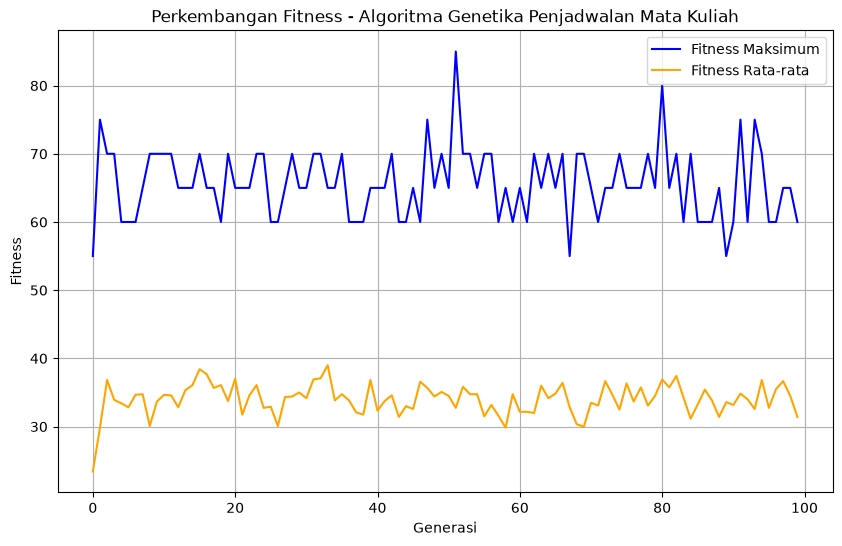

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, 100), hist_max, 'b-', label='Fitness Maksimum')
plt.plot(range(0, 100), hist_avg, 'orange', label='Fitness Rata-rata')
plt.title('Perkembangan Fitness - Algoritma Genetika Penjadwalan Mata Kuliah')
plt.xlabel('Generasi')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.savefig('results/fitness_evolution.png', dpi=150)
plt.show()

In [ ]:
print("Analisis:")
print(f"- Fitness terbaik: {best_fitness:.2f}")
print(f"- Total konflik: {best_conflicts}")
print(f"- Fitness awal: {hist_max[0]:.2f}")
print(f"- Fitness akhir: {hist_max[-1]:.2f}")
print(f"- Peningkatan: {(hist_max[-1] - hist_max[0]):.2f} poin")

Analisis:
- Fitness terbaik: 85.00
- Total konflik: 3
- Fitness awal: 55.00
- Fitness akhir: 60.00
- Peningkatan: 5.00 poin
